# CSC3042F 2026 - Assignment 2
# Encoder-Decoder Models for Grapheme-to-Phoneme Conversion

**AI Usage Statement:**
I used ChatGPT as a debugging and what is needed for me in this assignment, understanding some concerpts and some of the presentation was inspired from it. All implementation decisions and written analysis are mine. No section of this notebook was generated from scratch by an AI tool. I got structural inspiration of the report from ChatGPT and Grammaly for critiques.

In [1]:
## Imports and Reproducibility Seeds

In [2]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
import editdistance
import os

# Fix all random seeds for reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


---
## Section 1: Data Processing

loading the CMU Pronouncing Dictionary splits, build character and phoneme vocabularies from training data, and set up padded DataLoaders.

In [ ]:
# Special token indices
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

def build_vocab(sequences, split_tokens=False):
    
    # Build a token-to-index vocabulary from a list of strings.
    # Reserves <PAD>=0, <SOS>=1, <EOS>=2, <UNK>=3 at fixed positions.
    
    
    tok_to_idx = {'<PAD>': PAD_IDX, '<SOS>': SOS_IDX, '<EOS>': EOS_IDX, '<UNK>': UNK_IDX}
    
    for seq in sequences:
        
        seq = str(seq)
        tokens = seq.split() if split_tokens else list(seq)
        
        for tok in tokens:
            
            if tok not in tok_to_idx:
                
                tok_to_idx[tok] = len(tok_to_idx)
                
    idx_to_tok = {v: k for k, v in tok_to_idx.items()}
    return tok_to_idx, idx_to_tok


# Load CSV files
DATA_DIR = '/data'


train_df = pd.read_csv(os.path.join(DATA_DIR, 'g2p_train.csv'))
val_df   = pd.read_csv(os.path.join(DATA_DIR, 'g2p_val.csv'))
test_df  = pd.read_csv(os.path.join(DATA_DIR, 'g2p_test.csv'))

# This part was AI modified to help me with the NaN values in the CSV files.
# Some rows have NaN in 'word' or 'phonemes' (empty lines, malformed CSV).
# These cause 'float is not iterable' in build_vocab — we drop them here.
def clean_df(df, name):
    before = len(df)
    df = df.dropna(subset=['word', 'phonemes']).copy()
    df['word']     = df['word'].astype(str).str.strip().str.lower()
    df['phonemes'] = df['phonemes'].astype(str).str.strip()
    df = df[(df['word'] != '') & (df['phonemes'] != '')]
    df = df.reset_index(drop=True)
    dropped = before - len(df)
    if dropped:
        print(f'[{name}] Dropped {dropped} bad rows. Remaining: {len(df):,}')
    return df

train_df = clean_df(train_df, 'train')
val_df   = clean_df(val_df,   'val')
test_df  = clean_df(test_df,  'test')

print(f'Train size : {len(train_df):,}')
print(f'Val size   : {len(val_df):,}')
print(f'Test size  : {len(test_df):,}')
print()
print(train_df.head(3))

# Build vocabularies from training data ONLY
char_to_idx, idx_to_char = build_vocab(train_df['word'].tolist(),     split_tokens=False)
phon_to_idx, idx_to_phon = build_vocab(train_df['phonemes'].tolist(), split_tokens=True)

SRC_VOCAB_SIZE = len(char_to_idx)
TGT_VOCAB_SIZE = len(phon_to_idx)

print(f'\nCharacter vocabulary size : {SRC_VOCAB_SIZE}')
print(f'Phoneme   vocabulary size : {TGT_VOCAB_SIZE}')

[train] Dropped 2 bad rows. Remaining: 92,424
Train size : 92,424
Val size   : 11,553
Test size  : 11,554

        word                  phonemes
0      vigil            V IH1 JH AH0 L
1  ethelinda  EH0 TH EH0 L IY1 N D AH0
2      yaney               Y EY1 N IY0

Character vocabulary size : 30
Phoneme   vocabulary size : 73


In [4]:
class G2PDataset(Dataset):
    
    # Encodes (word, phoneme) pairs as integer index sequences.
    # Each source sequence is a list of character indices.
    
    def __init__(self, df, char_to_idx, phon_to_idx):
        self.src = []
        self.tgt = []
        for _, row in df.iterrows():
            if pd.isna(row['word']) or pd.isna(row['phonemes']):
                continue
            src_ids = [char_to_idx.get(ch, UNK_IDX) for ch in row['word']]
            tgt_ids = ([SOS_IDX] + [phon_to_idx.get(p, UNK_IDX) for p in row['phonemes'].split()] + [EOS_IDX])
            self.src.append(torch.tensor(src_ids, dtype=torch.long))
            self.tgt.append(torch.tensor(tgt_ids, dtype=torch.long))

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        return self.src[idx], self.tgt[idx]


def collate_fn(batch):
    
    # Pad source and target sequences within a batch to the same length.
    # Uses PAD_IDX=0 for padding.
    
    src_seqs, tgt_seqs = zip(*batch)
    src_padded = pad_sequence(src_seqs, batch_first=True, padding_value=PAD_IDX)
    tgt_padded = pad_sequence(tgt_seqs, batch_first=True, padding_value=PAD_IDX)
    return src_padded, tgt_padded


BATCH_SIZE = 128

train_dataset = G2PDataset(train_df, char_to_idx, phon_to_idx)
val_dataset   = G2PDataset(val_df,   char_to_idx, phon_to_idx)
test_dataset  = G2PDataset(test_df,  char_to_idx, phon_to_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=0)

print(f'Train batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# Inspecting one batch
_src, _tgt = next(iter(train_loader))
print(f'\nSrc batch shape : {_src.shape}   (batch, src_len)')
print(f'Tgt batch shape : {_tgt.shape}   (batch, tgt_len)')

Train batches : 723
Val   batches : 91
Test  batches : 91

Src batch shape : torch.Size([128, 14])   (batch, src_len)
Tgt batch shape : torch.Size([128, 16])   (batch, tgt_len)


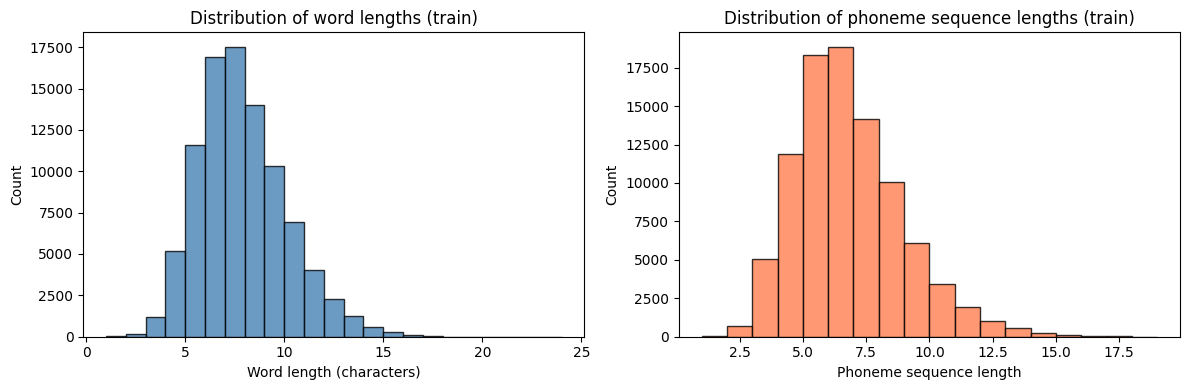

Word length  - mean: 7.4, max: 33
Phoneme len  - mean: 6.3, max: 32


In [5]:
# Vocabulary and length histograms

word_lengths = train_df['word'].apply(len).tolist()
phon_lengths = train_df['phonemes'].apply(lambda s: len(s.split())).tolist()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(word_lengths, bins=range(1, 25), edgecolor='black', color='steelblue', alpha=0.8)
axes[0].set_xlabel('Word length (characters)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of word lengths (train)')

axes[1].hist(phon_lengths, bins=range(1, 20), edgecolor='black', color='coral', alpha=0.8)
axes[1].set_xlabel('Phoneme sequence length')
axes[1].set_ylabel('Count')
axes[1].set_title('Distribution of phoneme sequence lengths (train)')

plt.tight_layout()
plt.savefig('length_histograms.png', dpi=150)
plt.show()
print(f'Word length  - mean: {np.mean(word_lengths):.1f}, max: {max(word_lengths)}')
print(f'Phoneme len  - mean: {np.mean(phon_lengths):.1f}, max: {max(phon_lengths)}')

---
## Section 2 - LSTM Cell

Adapted this section from the LSTM tutorial notebook. Use **separate** 'nn.Linear' layers for the input and hidden projections (one per gate), each with 'bias=False', plus a learnable 'nn.Parameter' bias per gate. This makes the mapping from the assignment equations to the code explicit:

$$f_t = \sigma(W_f x_t + U_f h_{t-1} + b_f)$$

In [ ]:
class LSTMCell(nn.Module):
    
    # Single LSTM cell implementing the above equation.
    # Uses separate nn.Linear layers for W (input) and U (hidden) projections
    # per gate, plus a learned bias parameter per gate.
    
    def __init__(self, input_size: int, hidden_size: int):
        super().__init__()
        self.hidden_size = hidden_size

        # Forget gate - Wf, Uf, bf
        self.Wf = nn.Linear(input_size,  hidden_size, bias=False)
        self.Uf = nn.Linear(hidden_size, hidden_size, bias=False)
        self.bf = nn.Parameter(torch.zeros(hidden_size))

        # Input gate - Wi, Ui, bi
        self.Wi = nn.Linear(input_size,  hidden_size, bias=False)
        self.Ui = nn.Linear(hidden_size, hidden_size, bias=False)
        self.bi = nn.Parameter(torch.zeros(hidden_size))

        # Output gate - Wo, Uo, bo
        self.Wo = nn.Linear(input_size,  hidden_size, bias=False)
        self.Uo = nn.Linear(hidden_size, hidden_size, bias=False)
        self.bo = nn.Parameter(torch.zeros(hidden_size))

        # Cell candidate - Wc, Uc, bc
        self.Wc = nn.Linear(input_size,  hidden_size, bias=False)
        self.Uc = nn.Linear(hidden_size, hidden_size, bias=False)
        self.bc = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, x, h, c):
        
        # A.1  Forget gate
        ft = torch.sigmoid(self.Wf(x) + self.Uf(h) + self.bf)
        # A.2  Input gate
        it = torch.sigmoid(self.Wi(x) + self.Ui(h) + self.bi)
        # A.3  Output gate
        ot = torch.sigmoid(self.Wo(x) + self.Uo(h) + self.bo)
        # A.4  Cell candidate
        ct_tilde = torch.tanh(self.Wc(x) + self.Uc(h) + self.bc)
        # A.5  New cell state
        c_new = ft * c + it * ct_tilde
        # A.6  New hidden state
        h_new = ot * torch.tanh(c_new)
        return h_new, c_new


# some sanity check

torch.manual_seed(0)
_cell = LSTMCell(input_size=8, hidden_size=16)
_x = torch.randn(4, 8)
_h = torch.zeros(4, 16)
_c = torch.zeros(4, 16)
_h_new, _c_new = _cell(_x, _h, _c)
print(f'LSTMCell output h shape: {_h_new.shape}') 
print(f'LSTMCell output c shape: {_c_new.shape}') 

LSTMCell output h shape: torch.Size([4, 16])
LSTMCell output c shape: torch.Size([4, 16])


---
## Section 3: Encoder-Decoder Implementation

### 3a. Encoder

The encoder embeds each source character, then runs a multi-layer LSTM over the sequence, returning all hidden states ('all_h') and the final states '(h_n, c_n)'.

In [7]:
class Encoder(nn.Module):
    
    # LSTM encoder for the source character sequence.
    
    def __init__(self, src_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers  = num_layers

        self.embedding = nn.Embedding(src_vocab_size, embed_dim, padding_idx=PAD_IDX)

        # One LSTMCell per layer; layer 0 takes embed_dim input,
        
        self.cells = nn.ModuleList([LSTMCell(embed_dim if l == 0 else hidden_size, hidden_size) for l in range(num_layers)])

    def forward(self, src):
        
        batch_size, src_len = src.shape
        emb = self.embedding(src)           # (batch, src_len, embed_dim)
        emb = emb.transpose(0, 1)           # (src_len, batch, embed_dim)

        # Initialising all hidden layers and cell states to zero
        h = [torch.zeros(batch_size, self.hidden_size, device=src.device) for _ in range(self.num_layers)]
        c = [torch.zeros(batch_size, self.hidden_size, device=src.device) for _ in range(self.num_layers)]

        all_h = []
        for t in range(src_len):            
            x_t = emb[t]                   # (batch, embed_dim)
            for l, cell in enumerate(self.cells):
                h[l], c[l] = cell(x_t, h[l], c[l])
                x_t = h[l]                 # pass top of stack upward
            all_h.append(h[-1])            # collect top-layer hidden state

        all_h = torch.stack(all_h, dim=0)  # (src_len, batch, hidden_size)
        h_n   = torch.stack(h,     dim=0)  # (num_layers, batch, hidden_size)
        c_n   = torch.stack(c,     dim=0)  # (num_layers, batch, hidden_size)
        return all_h, (h_n, c_n)

### 3b & 3c - Decoder (all three context modes)

A single 'Decoder' class handles all three setups via 'context_mode':
- '"none"' = Setup 1: no context, standard LSTM
- '"fixed"' = Setup 2: fixed context vector z = h_enc_n fed to every gate at every step
- '"attn"' = Setup 3: dynamic context zt computed from dot-product attention over all_h

For Setups 2 and 3, each gate gains a 'V' weight matrix that projects the context vector into hidden space; exactly one 'nn.Linear' per gate.

In [8]:
class ContextLSTMCell(nn.Module):
    
    # LSTM cell extended with a context vector input (for Setups 2 and 3).
    # Each gate has an additional V weight matrix that projects the context z.
    
    def __init__(self, input_size: int, hidden_size: int, context_size: int):
        super().__init__()
        self.hidden_size = hidden_size

        # W matrices (act on previous target embedding)
        self.Wf = nn.Linear(input_size,   hidden_size, bias=False)
        self.Wi = nn.Linear(input_size,   hidden_size, bias=False)
        self.Wo = nn.Linear(input_size,   hidden_size, bias=False)
        self.Wc = nn.Linear(input_size,   hidden_size, bias=False)

        # U matrices (act on previous hidden state)
        self.Uf = nn.Linear(hidden_size,  hidden_size, bias=False)
        self.Ui = nn.Linear(hidden_size,  hidden_size, bias=False)
        self.Uo = nn.Linear(hidden_size,  hidden_size, bias=False)
        self.Uc = nn.Linear(hidden_size,  hidden_size, bias=False)

        # V matrices (act on context vector z)
        self.Vf = nn.Linear(context_size, hidden_size, bias=False)
        self.Vi = nn.Linear(context_size, hidden_size, bias=False)
        self.Vo = nn.Linear(context_size, hidden_size, bias=False)
        self.Vc = nn.Linear(context_size, hidden_size, bias=False)

        # Bias parameters
        self.bf = nn.Parameter(torch.zeros(hidden_size))
        self.bi = nn.Parameter(torch.zeros(hidden_size))
        self.bo = nn.Parameter(torch.zeros(hidden_size))
        self.bc = nn.Parameter(torch.zeros(hidden_size))

    def forward(self, y, h, c, z):
        
       
        #  y:(batch, input_size)
        # h: (batch, hidden_size)
        # c: (batch, hidden_size)
        # z: (batch, context_size)
        
        ft = torch.sigmoid(self.Wf(y) + self.Uf(h) + self.Vf(z) + self.bf)
        it = torch.sigmoid(self.Wi(y) + self.Ui(h) + self.Vi(z) + self.bi)
        ot = torch.sigmoid(self.Wo(y) + self.Uo(h) + self.Vo(z) + self.bo)
        ct_tilde = torch.tanh(self.Wc(y) + self.Uc(h) + self.Vc(z) + self.bc)
        c_new = ft * c + it * ct_tilde
        h_new = ot * torch.tanh(c_new)
        return h_new, c_new


class Decoder(nn.Module):
    
    #LSTM decoder supporting three context modes:
        # none  - Setup 1: bottleneck baseline 
        # fixed - Setup 2: fixed context vector 
        # attn  - Setup 3: dot-product attention 
    
    def __init__(self, tgt_vocab_size: int, embed_dim: int, hidden_size: int, num_layers: int = 1, context_mode: str = 'none'):
        super().__init__()
        assert context_mode in ('none', 'fixed', 'attn'), \
            f"context_mode must be 'none', 'fixed', or 'attn'; got '{context_mode}'"
        self.hidden_size  = hidden_size
        self.num_layers   = num_layers
        self.context_mode = context_mode

        self.embedding = nn.Embedding(tgt_vocab_size, embed_dim, padding_idx=PAD_IDX)

        if context_mode == 'none':
            # Standard LSTM cells — no context pathway
            self.cells = nn.ModuleList([
                LSTMCell(embed_dim if l == 0 else hidden_size, hidden_size)
                for l in range(num_layers)
            ])
        else:
            # context only enters the bottom layer
            self.cells = nn.ModuleList([
                ContextLSTMCell(embed_dim if l == 0 else hidden_size, hidden_size, hidden_size)
                if l == 0
                else LSTMCell(hidden_size, hidden_size)
                for l in range(num_layers)
            ])

        # Output projection: hidden state → logits over phoneme vocabulary
        self.fc_out = nn.Linear(hidden_size, tgt_vocab_size)

    def _compute_attention(self, h_dec, encoder_outputs):
        # Computing a dot-product attention context vector zt and weights alpha.
        
        src_len = encoder_outputs.shape[0]
        
        # e_{t,i} = h_dec · h_enc_i  for all i 
        # encoder_outputs: (src_len, batch, H)  ->  (batch, src_len, H)
        enc = encoder_outputs.permute(1, 0, 2)          # (batch, src_len, H)
        
        # h_dec unsqueeze -> (batch, H, 1)
        scores = torch.bmm(enc, h_dec.unsqueeze(2))     # (batch, src_len, 1)
        scores = scores.squeeze(2)                       # (batch, src_len)
        
        # alpha_{t,i} = softmax(e_{t,i})  
        alpha = torch.softmax(scores, dim=1)             # (batch, src_len)
        
        # zt = sum_i alpha_{t,i} * h_enc_i 
        zt = torch.bmm(alpha.unsqueeze(1), enc)          # (batch, 1, H)
        zt = zt.squeeze(1)                               # (batch, H)
        
        return zt, alpha
    

    def forward(self, tgt, hidden, encoder_outputs=None):
        
        # Running the decoder over a full target sequence, training mode.
        
        batch_size, tgt_len = tgt.shape
        emb = self.embedding(tgt)            # (batch, tgt_len, embed_dim)
        emb = emb.transpose(0, 1)            # (tgt_len, batch, embed_dim)

        h0, c0 = hidden
        h = [h0[l] for l in range(self.num_layers)]
        c = [c0[l] for l in range(self.num_layers)]

        # Fixed context: z = h_enc_n 
        if self.context_mode == 'fixed':
            z = h0[-1]                       # (batch, hidden_size)

        all_logits = []
        for t in range(tgt_len):
            y_t = emb[t]                     # (batch, embed_dim)

            if self.context_mode == 'none':
                
                for l, cell in enumerate(self.cells):
                    h[l], c[l] = cell(y_t, h[l], c[l])
                    y_t = h[l]

            elif self.context_mode == 'fixed':
               
                h[0], c[0] = self.cells[0](y_t, h[0], c[0], z)
                y_t = h[0]
                for l in range(1, self.num_layers):
                    h[l], c[l] = self.cells[l](y_t, h[l], c[l])
                    y_t = h[l]

            else:  # attn
                zt, _ = self._compute_attention(h[0], encoder_outputs)
                h[0], c[0] = self.cells[0](y_t, h[0], c[0], zt)
                y_t = h[0]
                for l in range(1, self.num_layers):
                    h[l], c[l] = self.cells[l](y_t, h[l], c[l])
                    y_t = h[l]

            logit = self.fc_out(h[-1])       # (batch, tgt_vocab_size)
            all_logits.append(logit)

        logits = torch.stack(all_logits, dim=1)  # (batch, tgt_len, tgt_vocab_size)
        h_n = torch.stack(h, dim=0)
        c_n = torch.stack(c, dim=0)
        return logits, (h_n, c_n)

In [9]:
class Seq2Seq(nn.Module):
    
    # Seq2Seq is wrapper around Encoder and Decoder.
    # Handling teacher during training and decoding
    
    def __init__(self, encoder: Encoder, decoder: Decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src, tgt, teacher_forcing: bool = True):
        
        encoder_outputs, (h_n, c_n) = self.encoder(src) 

        # initialise decoder
        decoder_input = tgt[:, :-1]      # (batch, tgt_len-1): <SOS> 
        logits, _ = self.decoder(
            decoder_input,
            (h_n, c_n),
            encoder_outputs=encoder_outputs if self.decoder.context_mode == 'attn' else None
        )
        return logits                    # predicts tgt[:, 1:]<EOS>

    @torch.no_grad()
    def greedy_decode(self, src, max_len: int = 30):
        
        # Greedy decoding,
        # Stops when <EOS> is predicted or max_len is reached.
        
        self.eval()
        batch_size = src.shape[0]
        encoder_outputs, (h_n, c_n) = self.encoder(src)

        h = [h_n[l] for l in range(self.decoder.num_layers)]
        c = [c_n[l] for l in range(self.decoder.num_layers)]

        if self.decoder.context_mode == 'fixed':
            z = h_n[-1]

        # Start with <SOS> 
        current_token = torch.full((batch_size,), SOS_IDX, dtype=torch.long, device=src.device)
        finished      = torch.zeros(batch_size, dtype=torch.bool, device=src.device)

        predictions  = [[] for _ in range(batch_size)]
        attn_weights = []   

        for _ in range(max_len):
            y_t = self.decoder.embedding(current_token)  # (batch, embed_dim)

            if self.decoder.context_mode == 'none':
                for l, cell in enumerate(self.decoder.cells):
                    h[l], c[l] = cell(y_t, h[l], c[l])
                    y_t = h[l]

            elif self.decoder.context_mode == 'fixed':
                h[0], c[0] = self.decoder.cells[0](y_t, h[0], c[0], z)
                y_t = h[0]
                for l in range(1, self.decoder.num_layers):
                    h[l], c[l] = self.decoder.cells[l](y_t, h[l], c[l])
                    y_t = h[l]

            else:  # attn
                zt, alpha = self.decoder._compute_attention(h[0], encoder_outputs)
                attn_weights.append(alpha.cpu())  
                h[0], c[0] = self.decoder.cells[0](y_t, h[0], c[0], zt)
                y_t = h[0]
                for l in range(1, self.decoder.num_layers):
                    h[l], c[l] = self.decoder.cells[l](y_t, h[l], c[l])
                    y_t = h[l]

            logit = self.decoder.fc_out(h[-1])      # (batch, vocab)
            pred  = logit.argmax(dim=1)              # (batch,)
            current_token = pred

            for b in range(batch_size):
                if not finished[b]:
                    if pred[b].item() == EOS_IDX:
                        finished[b] = True
                    else:
                        predictions[b].append(pred[b].item())

            if finished.all():
                break

        return predictions, attn_weights


# architecture checking 
# 
def build_model(context_mode, embed_dim=64, hidden_size=128):
   
    enc = Encoder(SRC_VOCAB_SIZE, embed_dim, hidden_size, num_layers=1)
    dec = Decoder(TGT_VOCAB_SIZE, embed_dim, hidden_size, num_layers=1, context_mode=context_mode)
    return Seq2Seq(enc, dec).to(device)

for mode in ('none', 'fixed', 'attn'):
    m = build_model(mode)
    _s, _t = _src.to(device), _tgt.to(device)
    out = m(_s, _t)
    print(f'context_mode={mode!r:7s}  logits shape: {out.shape}') 

context_mode='none'   logits shape: torch.Size([128, 15, 73])
context_mode='fixed'  logits shape: torch.Size([128, 15, 73])
context_mode='attn'   logits shape: torch.Size([128, 15, 73])


---
## Section 4: Training

Using cross-entropy loss with 'ignore_index=PAD_IDX', the Adam optimiser, and gradient clipping ('max_norm=1.0') to stabilise the hand-rolled LSTM.

**Stopping criterion:** early stopping on validation loss with patience = 5 epochs. If validation loss does not improve for 5 consecutive epochs stops and restores the best checkpoint. This avoids overfitting and saves compute.

In [10]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)


def train_epoch(model, loader, optimiser):
    
    # Running one training epoch.
    
    model.train()
    total_loss = 0.0
    for src, tgt in loader:
        src, tgt = src.to(device), tgt.to(device)

        optimiser.zero_grad()
        logits = model(src, tgt, teacher_forcing=True)  # (batch, tgt_len-1, vocab)

        # Target: tgt[:, 1:] is the "gold" shifted by one (predicting next token)
        targets = tgt[:, 1:]                             # (batch, tgt_len-1)

        # CrossEntropyLoss expects (N,C) and (N,)
        loss = criterion(
            logits.reshape(-1, TGT_VOCAB_SIZE),
            targets.reshape(-1)
        )
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimiser.step()
        total_loss += loss.item()

    return total_loss / len(loader)


def evaluate_loss(model, loader):
    
    # Compute average cross-entropy loss on a held-out set.
    
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            logits  = model(src, tgt, teacher_forcing=True)
            targets = tgt[:, 1:]
            loss = criterion(
                logits.reshape(-1, TGT_VOCAB_SIZE),
                targets.reshape(-1)
            )
            total_loss += loss.item()
    return total_loss / len(loader)


def train_model(model, train_loader, val_loader, lr=1e-3,
                max_epochs=30, patience=5, verbose=True):
    
    # Trainning with early stopping on validation loss.
    
    optimiser    = optim.Adam(model.parameters(), lr=lr)
    best_val     = float('inf')
    wait         = 0
    best_state   = None
    train_losses = []
    val_losses   = []

    for epoch in range(1, max_epochs + 1):
        tr_loss  = train_epoch(model, train_loader, optimiser)
        val_loss = evaluate_loss(model, val_loader)
        train_losses.append(tr_loss)
        val_losses.append(val_loss)

        if verbose:
            print(f'Epoch {epoch:3d}  train_loss={tr_loss:.4f}  val_loss={val_loss:.4f}')

        # Early stopping if nesessary
        if val_loss < best_val:
            best_val   = val_loss
            wait       = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f'Early stopping at epoch {epoch} (patience={patience})')
                break

    # Restores best weights
    if best_state is not None:
        model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

    return train_losses, val_losses

---
## Section 5: Hyperparameter Tuning

Grid-searching over learning rate, embedding dim, and hidden size using Setup 1 (bottleneck) with 8 epochs per config. We pick the config with the lowest validation per.

**Validation PER** is computed via 'editdistance' on predicted vs. reference phoneme token lists.

In [11]:
def compute_per_and_acc(model, loader, idx_to_phon, max_len=30):
    
    # Computing Phoneme Error Rate (PER) and word-level accuracy on a DataLoader.
    
    model.eval()
    total_per   = 0.0
    total_exact = 0
    total_words = 0

    with torch.no_grad():
        for src, tgt in loader:
            src = src.to(device)
            preds, _ = model.greedy_decode(src, max_len=max_len)

            for b in range(src.shape[0]):
                #
                ref_ids  = tgt[b].tolist()
                ref_phon = [idx_to_phon[i] for i in ref_ids if i not in (SOS_IDX, EOS_IDX, PAD_IDX)]
                pred_phon = [idx_to_phon.get(i, '<UNK>') for i in preds[b]]

                ed = editdistance.eval(pred_phon, ref_phon)
                per = ed / max(len(ref_phon), 1)
                total_per   += per
                total_exact += int(pred_phon == ref_phon)
                total_words += 1

    return total_per / total_words, total_exact / total_words


# Grid search over hyperparameters for the bottleneck baseline
TUNE_EPOCHS = 8

lr_values    = [1e-4, 5e-4, 1e-3]
embed_values = [32,   64,   128]
hidden_values= [64,   128,  256]

tuning_results = []

for lr in lr_values:
    for embed_dim in embed_values:
        for hidden_size in hidden_values:
            torch.manual_seed(SEED)
            m = build_model('none', embed_dim=embed_dim, hidden_size=hidden_size)
            m_enc = Encoder(SRC_VOCAB_SIZE, embed_dim, hidden_size, num_layers=1)
            m_dec = Decoder(TGT_VOCAB_SIZE, embed_dim, hidden_size, num_layers=1, context_mode='none')
            m = Seq2Seq(m_enc, m_dec).to(device)

            train_model(m, train_loader, val_loader, lr=lr, max_epochs=TUNE_EPOCHS, patience=TUNE_EPOCHS, verbose=False)

            val_per, val_acc = compute_per_and_acc(m, val_loader, idx_to_phon)
            print(f'lr={lr:.0e}  embed={embed_dim:3d}  hidden={hidden_size:3d}  ' f'val_PER={val_per:.4f}  val_acc={val_acc:.4f}')
            tuning_results.append({'lr': lr, 'embed_dim': embed_dim, 'hidden_size': hidden_size, 'val_PER': val_per, 'val_acc': val_acc})

lr=1e-04  embed= 32  hidden= 64  val_PER=0.7375  val_acc=0.0037
lr=1e-04  embed= 32  hidden=128  val_PER=0.5275  val_acc=0.0518
lr=1e-04  embed= 32  hidden=256  val_PER=0.3558  val_acc=0.1935
lr=1e-04  embed= 64  hidden= 64  val_PER=0.6161  val_acc=0.0205
lr=1e-04  embed= 64  hidden=128  val_PER=0.4462  val_acc=0.1088
lr=1e-04  embed= 64  hidden=256  val_PER=0.2981  val_acc=0.2606
lr=1e-04  embed=128  hidden= 64  val_PER=0.5840  val_acc=0.0263
lr=1e-04  embed=128  hidden=128  val_PER=0.3883  val_acc=0.1623
lr=1e-04  embed=128  hidden=256  val_PER=0.2665  val_acc=0.3059
lr=5e-04  embed= 32  hidden= 64  val_PER=0.3650  val_acc=0.1895
lr=5e-04  embed= 32  hidden=128  val_PER=0.2233  val_acc=0.3795
lr=5e-04  embed= 32  hidden=256  val_PER=0.1576  val_acc=0.4968
lr=5e-04  embed= 64  hidden= 64  val_PER=0.3357  val_acc=0.2263
lr=5e-04  embed= 64  hidden=128  val_PER=0.2209  val_acc=0.3814
lr=5e-04  embed= 64  hidden=256  val_PER=0.1472  val_acc=0.5135
lr=5e-04  embed=128  hidden= 64  val_PER

In [ ]:
# Tuning table and select best config
tune_df = pd.DataFrame(tuning_results).sort_values('val_PER')
print('Hyperparameter tuning results (sorted by val PER):')
print(tune_df.to_string(index=False))

best = tune_df.iloc[0]
BEST_LR     = best['lr']
BEST_EMBED  = int(best['embed_dim'])
BEST_HIDDEN = int(best['hidden_size'])

print(f'\nBest config *->* lr={BEST_LR}, embed_dim={BEST_EMBED}, hidden_size={BEST_HIDDEN}')
print(f'This configuration achieved the lowest validation PER = {best["val_PER"]:.4f}.')

Hyperparameter tuning results (sorted by val PER):
    lr  embed_dim  hidden_size  val_PER  val_acc
0.0010         32          256 0.129946 0.559076
0.0010         64          256 0.129947 0.559595
0.0010        128          256 0.131494 0.559422
0.0005        128          256 0.143432 0.531377
0.0005         64          256 0.147197 0.513546
0.0005         32          256 0.157597 0.496754
0.0010         64          128 0.173218 0.468104
0.0010        128          128 0.175178 0.464035
0.0010         32          128 0.179307 0.453129
0.0005        128          128 0.201756 0.417554
0.0005         64          128 0.220931 0.381373
0.0005         32          128 0.223337 0.379469
0.0010        128           64 0.262204 0.326409
0.0001        128          256 0.266471 0.305895
0.0010         64           64 0.269019 0.316368
0.0010         32           64 0.289176 0.287285
0.0001         64          256 0.298054 0.260625
0.0005        128           64 0.312410 0.256037
0.0005         64 

---
## Section 6: Architecture Comparison

Ttraining all three setups with the best hyperparameters, same random seed, and same early-stopping criterion.

In [ ]:
MAX_EPOCHS = 30
PATIENCE   = 5

models     = {}
histories  = {}
mode_names = {'none' : 'Setup 1 - No context (bottleneck)', 'fixed': 'Setup 2 - Fixed context vector', 'attn' : 'Setup 3 - Dot-product attention'}

for mode in ('none', 'fixed', 'attn'):
    print(f'\n=== Training {mode_names[mode]} ===')
    torch.manual_seed(SEED)
    enc = Encoder(SRC_VOCAB_SIZE, BEST_EMBED, BEST_HIDDEN, num_layers=1)
    dec = Decoder(TGT_VOCAB_SIZE, BEST_EMBED, BEST_HIDDEN, num_layers=1, context_mode=mode)
    model = Seq2Seq(enc, dec).to(device)

    tr_losses, val_losses = train_model(model, train_loader, val_loader,lr=BEST_LR, max_epochs=MAX_EPOCHS, patience=PATIENCE, verbose=True)
    models[mode]    = model
    histories[mode] = (tr_losses, val_losses)


=== Training Setup 1 — No context (bottleneck) ===
Epoch   1  train_loss=1.8659  val_loss=0.8661
Epoch   2  train_loss=0.6622  val_loss=0.5317
Epoch   3  train_loss=0.4604  val_loss=0.4262
Epoch   4  train_loss=0.3752  val_loss=0.3689
Epoch   5  train_loss=0.3243  val_loss=0.3486
Epoch   6  train_loss=0.2884  val_loss=0.3190
Epoch   7  train_loss=0.2606  val_loss=0.3110
Epoch   8  train_loss=0.2373  val_loss=0.3025
Epoch   9  train_loss=0.2177  val_loss=0.2943
Epoch  10  train_loss=0.1998  val_loss=0.2912
Epoch  11  train_loss=0.1856  val_loss=0.2877
Epoch  12  train_loss=0.1700  val_loss=0.2928
Epoch  13  train_loss=0.1575  val_loss=0.2957
Epoch  14  train_loss=0.1450  val_loss=0.2959
Epoch  15  train_loss=0.1342  val_loss=0.3059
Epoch  16  train_loss=0.1240  val_loss=0.3116
Early stopping at epoch 16 (patience=5)

=== Training Setup 2 — Fixed context vector ===
Epoch   1  train_loss=1.8621  val_loss=0.8350
Epoch   2  train_loss=0.6468  val_loss=0.5101
Epoch   3  train_loss=0.4527  v

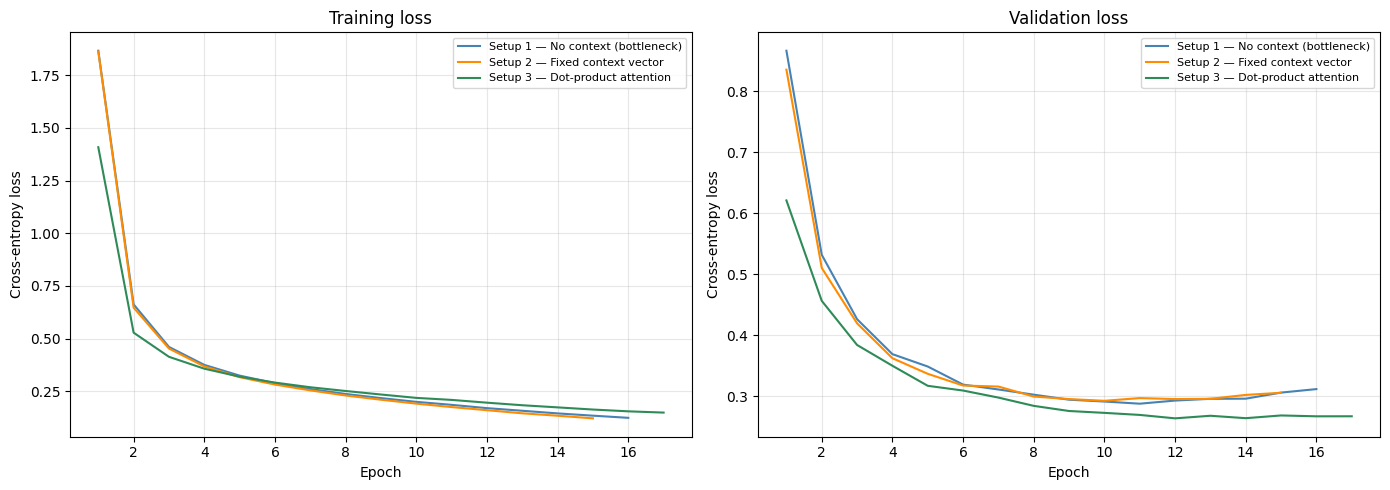

In [14]:
# Loss curves
colours = {'none': 'steelblue', 'fixed': 'darkorange', 'attn': 'seagreen'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for mode, (tr, val) in histories.items():
    epochs = range(1, len(tr) + 1)
    axes[0].plot(epochs, tr,  label=mode_names[mode], color=colours[mode])
    axes[1].plot(epochs, val, label=mode_names[mode], color=colours[mode])

axes[0].set_title('Training loss')
axes[1].set_title('Validation loss')
for ax in axes:
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Cross-entropy loss')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150)
plt.show()

---
## Section 7: Evaluation

We report **Phoneme Error Rate (PER)** and **Word Accuracy** on the test set for all three setups.

In [15]:
results = []
for mode in ('none', 'fixed', 'attn'):
    per, acc = compute_per_and_acc(models[mode], test_loader, idx_to_phon)
    results.append({'Setup': mode_names[mode], 'Test PER': round(per, 4), 'Word Acc': round(acc, 4)})
    print(f'{mode_names[mode]:40s}  PER={per:.4f}  WordAcc={acc:.4f}')

results_df = pd.DataFrame(results)
print('\n', results_df.to_string(index=False))

Setup 1 — No context (bottleneck)         PER=0.1299  WordAcc=0.5675
Setup 2 — Fixed context vector            PER=0.1292  WordAcc=0.5683
Setup 3 — Dot-product attention           PER=0.1207  WordAcc=0.5788

                             Setup  Test PER  Word Acc
Setup 1 — No context (bottleneck)    0.1299    0.5675
   Setup 2 — Fixed context vector    0.1292    0.5683
  Setup 3 — Dot-product attention    0.1207    0.5788


In [16]:
# Error analysis:
print('=== Error analysis: words where bottleneck (Setup 1) fails but attention (Setup 3) succeeds ===\n')

# Decode a small slice of the test set for comparison
analysis_src  = []
analysis_ref  = []
analysis_words= []

all_src_list = []
all_tgt_list = []

for src, tgt in test_loader:
    for i in range(src.shape[0]):
        all_src_list.append(src[i])   # storing each sample individually
        all_tgt_list.append(tgt[i])
    if len(all_src_list) >= 2000:
        break

all_src_list = all_src_list[:2000]
all_tgt_list = all_tgt_list[:2000]

# Re-pad and batch them uniformly so torch.cat works
from torch.nn.utils.rnn import pad_sequence
analysis_src = pad_sequence(all_src_list, batch_first=True, padding_value=PAD_IDX)
analysis_ref = pad_sequence(all_tgt_list, batch_first=True, padding_value=PAD_IDX)

# Decode with both models
preds_none, _ = models['none'].greedy_decode(analysis_src.to(device))
preds_attn, _ = models['attn'].greedy_decode(analysis_src.to(device))

fails_fixed_wins_attn = []
for b in range(analysis_src.shape[0]):
    ref_ids   = analysis_ref[b].tolist()
    ref_phon  = [idx_to_phon[i] for i in ref_ids if i not in (SOS_IDX, EOS_IDX, PAD_IDX)]
    pred_none = [idx_to_phon.get(i, '<UNK>') for i in preds_none[b]]
    pred_attn = [idx_to_phon.get(i, '<UNK>') for i in preds_attn[b]]

    word_chars = [idx_to_char.get(i, '?') for i in analysis_src[b].tolist() if i != PAD_IDX]
    word = ''.join(word_chars)

    none_correct = (pred_none == ref_phon)
    attn_correct = (pred_attn == ref_phon)

    if (not none_correct) and attn_correct: fails_fixed_wins_attn.append((word, ref_phon, pred_none, pred_attn))

print(f'Found {len(fails_fixed_wins_attn)} words where Setup 1 fails but Setup 3 succeeds.\n')
for word, ref, p1, p3 in fails_fixed_wins_attn[:5]:
    print(f'Word    : {word}')
    print(f'Ref     : {" ".join(ref)}')
    print(f'Setup 1 : {" ".join(p1)}')
    print(f'Setup 3 : {" ".join(p3)}')
    print()

=== Error analysis: words where bottleneck (Setup 1) fails but attention (Setup 3) succeeds ===

Found 200 words where Setup 1 fails but Setup 3 succeeds.

Word    : mcmorris
Ref     : M AH0 K M AO1 R AH0 S
Setup 1 : M AH0 K M AO1 R IH0 S
Setup 3 : M AH0 K M AO1 R AH0 S

Word    : vulgarization
Ref     : V AH2 L G ER0 IH0 Z EY1 SH AH0 N
Setup 1 : V AH2 L JH ER0 AH0 Z EY1 SH AH0 N
Setup 3 : V AH2 L G ER0 IH0 Z EY1 SH AH0 N

Word    : gattuso
Ref     : G AA0 T UW1 S OW0
Setup 1 : G AE1 T S UW2 OW0
Setup 3 : G AA0 T UW1 S OW0

Word    : brooding
Ref     : B R UW1 D IH0 NG
Setup 1 : B R UH1 D IH0 NG
Setup 3 : B R UW1 D IH0 NG

Word    : siddeley
Ref     : S IH1 D AH0 L IY0
Setup 1 : S IH1 D L IY0
Setup 3 : S IH1 D AH0 L IY0



---
## Section 8: Attention Visualisation (Option b)

I visualise the attention weight matrix a for five test words - at least two longer than 8 characters. The heatmap shows which input characters the decoder attends to when generating each output phoneme.

hello                → L OW1 L OW0
enough               → HH AW1 F
through              → TH R AH1 F
psychological        → S AY2 K AH0 L AA1 JH IH0 K AH0 L
straightforward      → S T R EY1 T F AO2 R W ER0 D


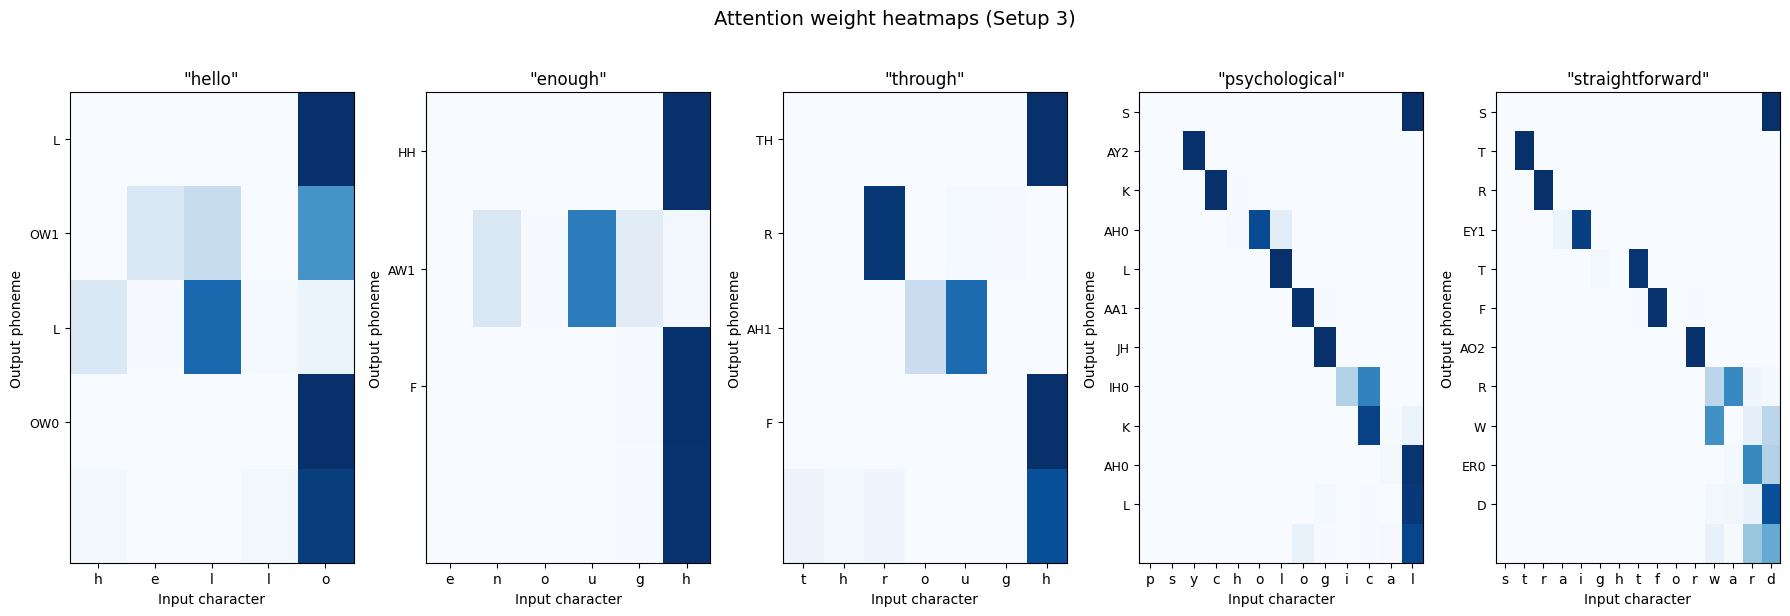

In [ ]:
def get_attention_for_word(model, word, char_to_idx, idx_to_phon, max_len=30):
    
    # Decode a single word with the attention model and return
    # the predicted phonemes and attention weight matrix.
    
    src_ids = [char_to_idx.get(ch, UNK_IDX) for ch in word]
    src = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)

    model.eval()
    preds, attn_weights = model.greedy_decode(src, max_len=max_len)

    phonemes  = [idx_to_phon.get(i, '<UNK>') for i in preds[0]]
    
    alpha_mat = torch.stack([aw[0] for aw in attn_weights], dim=0).numpy()  # (tgt_len, src_len)
    return phonemes, alpha_mat


def plot_attention(word, phonemes, alpha_mat, ax):
    
    # Plot attention heatmap.
    # x-axis: input characters; y-axis: output phonemes.
    
    chars = list(word)
    im = ax.imshow(alpha_mat, aspect='auto', cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(len(chars)))
    ax.set_xticklabels(chars, fontsize=10)
    ax.set_yticks(range(len(phonemes)))
    ax.set_yticklabels(phonemes, fontsize=9)
    ax.set_xlabel('Input character')
    ax.set_ylabel('Output phoneme')
    ax.set_title(f'"{word}"')
    return im


# Choose five words from the test set where attention helps and plot their attention heatmaps.
attn_words = ['hello', 'enough', 'through', 'psychological', 'straightforward']

fig, axes = plt.subplots(1, len(attn_words), figsize=(18, 6))
for ax, word in zip(axes, attn_words):
    phonemes, alpha_mat = get_attention_for_word(
        models['attn'], word, char_to_idx, idx_to_phon
    )
    plot_attention(word, phonemes, alpha_mat, ax)
    print(f'{word:20s} -> {" ".join(phonemes)}')

plt.suptitle('Attention weight heatmaps (Setup 3)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('attention_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()